# Preprocessing

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, 
)
from sklearn.impute import SimpleImputer
import joblib, os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

OUT_DIR = './processed'
os.makedirs(OUT_DIR, exist_ok=True)

data = pd.read_csv('../project/data.csv')

print(f'Shape : {data.shape}')
print(f'Columns ({len(data.columns)}):')
print(data.columns.tolist())
data.head(5)

Shape : (80000, 31)
Columns (31):
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']


,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [80]:
df = data.drop(columns=['student_id'], errors='ignore').copy()
df = data.drop(columns=['previous_gpa'], errors='ignore').copy()

print(f'Shape after ID drop: {df.shape}')
df.head(5)

Shape after ID drop: (80000, 30)


,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [81]:
print("Data Types: \n", df.dtypes)
print()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_%', ascending=False)

if missing_report.empty:
    print('No missing values found.')
else:
    print('Missing values found:')
    display(missing_report)

Data Types: 
 student_id                         int64
age                                int64
gender                            object
major                             object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating             float64
extracurricular_participation     object
semester                           int64
stress_level                     float64
dropout_risk                      object
social_activity                    int64
screen_time                      float64
study_environment                 object
access_to_tutoring                object
family_income_range               object
pa

In [82]:
"""
Getting a quick description of the dataset's numertical values.
"""
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,80000.0,139999.500000,23094.155105,100000.0,119999.75,139999.500000,159999.25,179999.0
age,80000.0,22.004288,3.745570,16.0,19.00,22.000000,25.00,28.0
study_hours_per_day,80000.0,4.174388,2.004135,0.0,2.80,4.125624,5.50,12.0
social_media_hours,80000.0,2.501366,1.445441,0.0,1.20,2.500000,3.80,5.0
netflix_hours,80000.0,1.997754,1.155992,0.0,1.00,2.000000,3.00,4.0
attendance_percentage,80000.0,69.967884,17.333015,40.0,55.00,69.900000,84.90,100.0
sleep_hours,80000.0,7.017417,1.467377,4.0,6.00,7.000000,8.00,12.0
exercise_frequency,80000.0,3.516587,2.291575,0.0,2.00,4.000000,6.00,7.0
mental_health_rating,80000.0,6.804107,1.921579,1.0,5.50,6.900000,8.20,10.0
semester,80000.0,4.497338,2.295312,1.0,2.00,5.000000,7.00,8.0


### Normalizing Boolean Data-Types

In [83]:
boolean_types = ['part_time_job', 'extracurricular_participation', 'access_to_tutoring', 'dropout_risk']

for col in boolean_types:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})
    )

print(df[['part_time_job']].value_counts())

part_time_job
0                40195
1                39805
Name: count, dtype: int64


### Dealing with Missing Values
- **Numeric Values** → Median (robust to outliers)
- **Categorical** → Mode (most frequent class)

In [84]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

num_predictors = [c for c in numeric_cols if c not in 'exam_score']
cat_predictors = [c for c in categorical_cols if c not in 'exam_score']

if num_predictors:
    num_imputer = SimpleImputer(strategy='median')
    df[num_predictors] = num_imputer.fit_transform(df[num_predictors])

if cat_predictors:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_predictors] = cat_imputer.fit_transform(df[cat_predictors])

print(f'Post-Imputation, there should be no missing values: {df.isnull().sum().sum()}')

Post-Imputation, there should be no missing values: 0


### Ordinal Encoding

In [85]:
ORDINAL_MAPS = {
    'parental_support_level': ['None', 'Low', 'Medium', 'High', 'Very High'],
    'parental_education_level': ['None', 'High School', 'Some College', "Bachelor's", "Master's", 'PhD'],
    'family_income_range': ['Low', 'Medium', 'High'],
    'diet_quality': ['Poor', 'Fair', 'Good'],
    'stress_level': ['Low', 'Moderate', 'High'],
    'motivation_level': ['Low', 'Medium', 'High'],
}

for col, order in ORDINAL_MAPS.items():
    if col not in df.columns:
        continue

    # Skip if already numeric
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f'  {col}: already numeric, skipping')
        continue

    mapping = {level: idx for idx, level in enumerate(order)}
    df[col] = df[col].map(mapping)

    median_val = df[col].median()
    if pd.isna(median_val):
        continue

    df[col] = df[col].fillna(median_val).astype('int64')
    print(f'  {col}: {mapping}')

print('\nOrdinal encoding complete.')

  parental_support_level: already numeric, skipping
  parental_education_level: {'None': 0, 'High School': 1, 'Some College': 2, "Bachelor's": 3, "Master's": 4, 'PhD': 5}
  family_income_range: {'Low': 0, 'Medium': 1, 'High': 2}
  diet_quality: {'Poor': 0, 'Fair': 1, 'Good': 2}
  stress_level: already numeric, skipping
  motivation_level: already numeric, skipping

Ordinal encoding complete.


###  One-Hot Encode Nominal Categoricals

In [86]:
TARGETS = ['dropout_risk']

# Identifying remaining object/string columns that weren't ordinal-encoded
nominal_cols = df.select_dtypes(include='string').columns.tolist()
nominal_cols = [c for c in nominal_cols if c not in TARGETS]

print(f'Nominal columns to one-hot encode: {nominal_cols}')

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
# Note for Harsh: drop_first=False → keep all dummies; regularization in Ridge/Lasso handles multicollinearity.

print(f'Shape after one-hot encoding: {df.shape}')
print('New columns added:')
print([c for c in df.columns if any(c.startswith(n+'_') for n in nominal_cols)])

Nominal columns to one-hot encode: []
Shape after one-hot encoding: (80000, 30)
New columns added:
[]


### Clip / Fix Known Range Anomalies

In [87]:
CLIP_RULES = {
    'age':                       (16, 28),
    'study_hours_per_day':       (0, 24),
    'social_media_hours':        (0, 24),
    'netflix_hours':             (0, 24),
    'screen_time':               (0, 24),
    'attendance_percentage':     (0, 100),
    'sleep_hours':               (0, 24),
    'exercise_frequency':        (0, 7),
    'mental_health_rating':      (1, 10),
    'exam_anxiety_score':        (1, 10),
    'time_management_score':     (1, 10),
    'exam_score':                (0, 100)
}

for col, (lo, hi) in CLIP_RULES.items():
    if col in df.columns:
        n_clipped = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_clipped:
            print(f'  {col}: clipped {n_clipped} values to [{lo}, {hi}]')
        df[col] = df[col].clip(lo, hi)

print('Range clipping complete.')

Range clipping complete.


### Feature Engineering

In [88]:
screen_cols = [c for c in ['social_media_hours', 'netflix_hours', 'screen_time'] if c in df.columns]
df['total_screen_time'] = df[screen_cols].sum(axis=1)

df['study_to_screen_ratio'] = df['study_hours_per_day'] / (df['total_screen_time'] + 0.1)

df['sleep_study_balance'] = df['sleep_hours'] + df['study_hours_per_day']

if 'stress_level' in df.columns and 'exam_anxiety_score' in df.columns:
    df['stress_anxiety_composite'] = (df['stress_level'] + df['exam_anxiety_score']) / 2

support_parts = [c for c in ['parental_support_level', 'access_to_tutoring'] if c in df.columns]
df['support_composite'] = df[support_parts].sum(axis=1)

df['wellness_score'] = (
    df.get('mental_health_rating', pd.Series(0, index=df.index))
    + (df.get('sleep_hours', pd.Series(0, index=df.index)) / 12 * 10)
    + (df.get('exercise_frequency', pd.Series(0, index=df.index)) / 7 * 10)
)

print('Engineered features added:')
eng_feats = ['total_screen_time', 'study_to_screen_ratio', 'sleep_study_balance',
             'stress_anxiety_composite', 'support_composite', 'wellness_score']
print(df[[f for f in eng_feats if f in df.columns]].describe().T.round(3))

Engineered features added:
                            count    mean    std    min     25%     50%  \
total_screen_time         80000.0  14.172  4.234  0.600  11.200  14.200   
study_to_screen_ratio     80000.0   0.300  0.143  0.000   0.206   0.291   
sleep_study_balance       80000.0  11.192  2.483  4.000   9.500  11.200   
stress_anxiety_composite  80000.0   6.760  1.326  3.000   5.850   6.850   
support_composite         80000.0   5.979  2.912  1.000   3.000   6.000   
wellness_score            80000.0  17.676  3.988  4.633  14.724  17.698   

                             75%     max  
total_screen_time         17.100  29.700  
study_to_screen_ratio      0.384   0.969  
sleep_study_balance       12.900  21.200  
stress_anxiety_composite   7.700  10.000  
support_composite          8.000  11.000  
wellness_score            20.655  30.000  


### Correlation / Collinearity Check

Top 15 features correlated with exam_score:
motivation_level            0.250
sleep_study_balance         0.249
stress_anxiety_composite   -0.247
study_hours_per_day         0.241
exam_anxiety_score         -0.236
study_to_screen_ratio       0.184
screen_time                 0.170
access_to_tutoring          0.120
stress_level               -0.119
total_screen_time           0.109
wellness_score              0.104
sleep_hours                 0.091
dropout_risk               -0.088
exercise_frequency          0.087
support_composite           0.014
Name: exam_score, dtype: float64


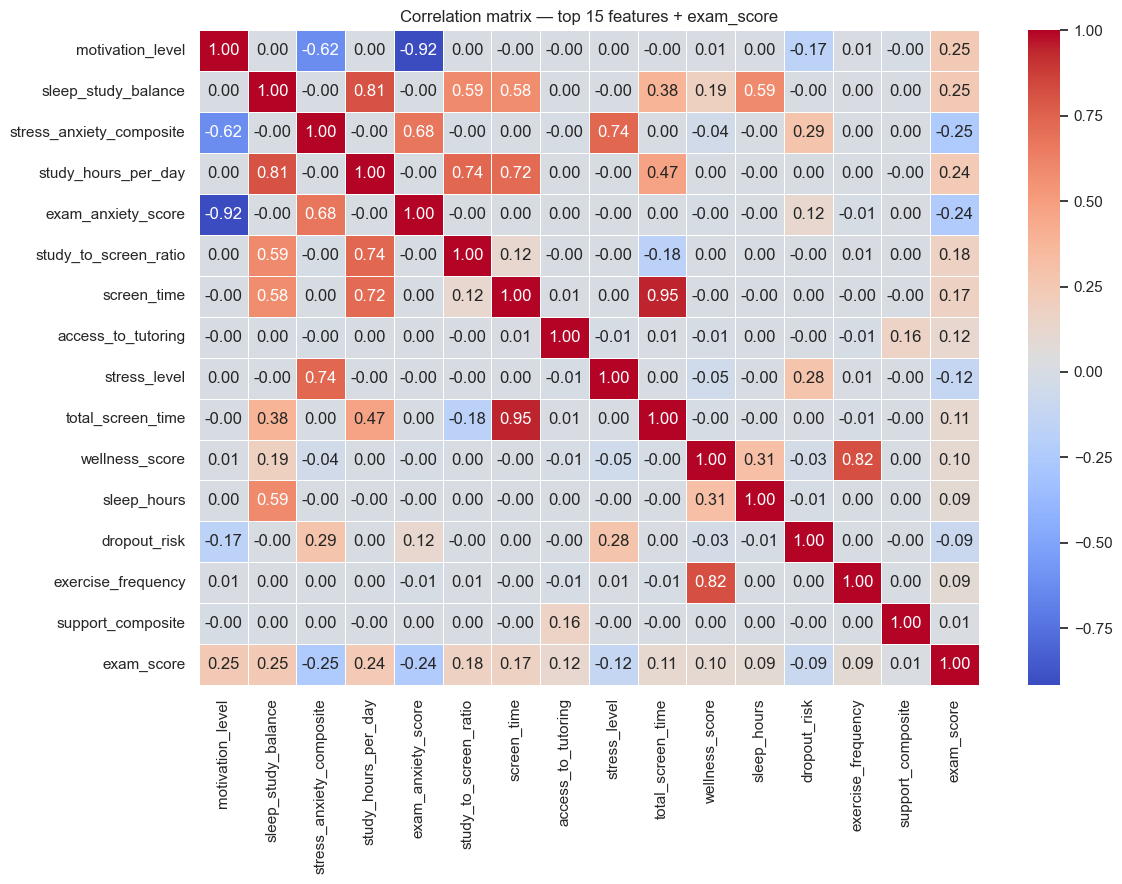

In [89]:
numeric_df = df.select_dtypes(include=[np.number])

if 'exam_score' in numeric_df.columns:
    target_corr = numeric_df.corr()['exam_score'].drop('exam_score').sort_values(key=abs, ascending=False)
    print('Top 15 features correlated with exam_score:')
    print(target_corr.head(15).round(3))

    top15 = target_corr.head(15).index.tolist() + ['exam_score']
    plt.figure(figsize=(12, 9))
    sns.heatmap(numeric_df[top15].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4)
    plt.title('Correlation matrix — top 15 features + exam_score')
    plt.tight_layout()
    plt.show()

In [90]:
corr_matrix = numeric_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'r'})
    .query('r > 0.90')
    .sort_values('r', ascending=False)
)

if high_corr_pairs.empty:
    print('No feature pairs with |r| > 0.90 found.')
else:
    print('High-correlation pairs (|r| > 0.90):')
    display(high_corr_pairs)
    print()
    print('Note: Ridge/Lasso handle collinearity via regularisation.')
    print('For vanilla Linear Regression consider dropping one column of each pair.')

High-correlation pairs (|r| > 0.90):


,feature_1,feature_2,r
418,parental_support_level,support_composite,0.985150
381,screen_time,total_screen_time,0.945057
420,motivation_level,exam_anxiety_score,0.916804



Note: Ridge/Lasso handle collinearity via regularisation.
For vanilla Linear Regression consider dropping one column of each pair.


In [91]:
COLS_TO_DROP_COLLINEAR = ['screen_time']
df.drop(columns=[c for c in COLS_TO_DROP_COLLINEAR if c in df.columns], inplace=True)
print(f'Dropped {COLS_TO_DROP_COLLINEAR}. Shape now: {df.shape}')

Dropped ['screen_time']. Shape now: (80000, 35)


---
## Finalise Feature / Target Split

In [92]:
y_reg  = df['exam_score'].copy()

y_clf  = df['dropout_risk'].copy()

X = df.drop(columns=['exam_score', 'dropout_risk']).copy()

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Feature matrix X : {X.shape}')
print(f'Regression target y_reg  : {y_reg.shape}  |  mean={y_reg.mean():.2f}, std={y_reg.std():.2f}')
print(f'Classification target y_clf : {y_clf.shape}  |  class balance {y_clf.value_counts(normalize=True).round(3).to_dict()}')
print()
print('Final feature list:')
print(X.columns.tolist())

Feature matrix X : (80000, 33)
Regression target y_reg  : (80000,)  |  mean=89.14, std=11.59
Classification target y_clf : (80000,)  |  class balance {0.0: 0.98, 1.0: 0.02}

Final feature list:
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'semester', 'stress_level', 'social_activity', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'total_screen_time', 'study_to_screen_ratio', 'sleep_study_balance', 'stress_anxiety_composite', 'support_composite', 'wellness_score']


---
##  Train / Validation / Test Split

We use an **80 / 10 / 10** split 


In [93]:
X_train_val, X_test, y_reg_train_val, y_reg_test, y_clf_train_val, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.10,
    random_state=RANDOM_STATE
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_train_val, y_reg_train_val, y_clf_train_val,
    test_size=0.1111,
    random_state=RANDOM_STATE
)

print('Split summary:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {len(arr):6d} rows  ({len(arr)/len(X)*100:.1f}%)')

train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)
assert not (train_idx & val_idx),  'Overlap between train and val!'
assert not (train_idx & test_idx), 'Overlap between train and test!'
assert not (val_idx   & test_idx), 'Overlap between val and test!'
print('No index overlap between splits — test set is locked.')

Split summary:
  Train   64000 rows  (80.0%)
  Val      8000 rows  (10.0%)
  Test     8000 rows  (10.0%)
No index overlap between splits — test set is locked.


---
## Scale Numeric Features

In [94]:
num_feature_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_feature_cols] = scaler.fit_transform(X_train[num_feature_cols])
X_val_scaled[num_feature_cols]   = scaler.transform(X_val[num_feature_cols])
X_test_scaled[num_feature_cols]  = scaler.transform(X_test[num_feature_cols])

print(f'Scaled {len(num_feature_cols)} numeric features using StandardScaler (fit on train only).')
print(f'Train mean (should be ~0): {X_train_scaled[num_feature_cols].mean().mean():.6f}')
print(f'Train std  (should be ~1): {X_train_scaled[num_feature_cols].std().mean():.6f}')

Scaled 28 numeric features using StandardScaler (fit on train only).
Train mean (should be ~0): -0.000000
Train std  (should be ~1): 1.000008


---
## Persist All Artefacts

We save:
- **Unscaled** splits → for Decision Trees 
- **Scaled** splits → for Linear, Ridge/Lasso, and Neural Networks

In [95]:
# Unscaled splits (tree-based models)
X_train.to_csv(f'{OUT_DIR}/X_train.csv', index=True)
X_val.to_csv(f'{OUT_DIR}/X_val.csv',     index=True)
X_test.to_csv(f'{OUT_DIR}/X_test.csv',   index=True)

# Scaled splits (linear / NN models)
X_train_scaled.to_csv(f'{OUT_DIR}/X_train_scaled.csv', index=True)
X_val_scaled.to_csv(f'{OUT_DIR}/X_val_scaled.csv',     index=True)
X_test_scaled.to_csv(f'{OUT_DIR}/X_test_scaled.csv',   index=True)

# Regression targets
y_reg_train.to_csv(f'{OUT_DIR}/y_reg_train.csv', index=True)
y_reg_val.to_csv(f'{OUT_DIR}/y_reg_val.csv',     index=True)
y_reg_test.to_csv(f'{OUT_DIR}/y_reg_test.csv',   index=True)

# Scaler and feature list
joblib.dump(scaler, f'{OUT_DIR}/standard_scaler.joblib')
pd.Series(X_train.columns.tolist()).to_csv(
    f'{OUT_DIR}/feature_list.csv', index=False, header=['feature']
)

print('Saved artefacts to', OUT_DIR)
print()
for f in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:<42s}  {size_kb:>8.1f} KB')

Saved artefacts to ./processed

  X_test.csv                                    1559.7 KB
  X_test_scaled.csv                             4626.1 KB
  X_train.csv                                  12471.0 KB
  X_train_scaled.csv                           37009.8 KB
  X_val.csv                                     1558.5 KB
  X_val_scaled.csv                              4626.4 KB
  feature_list.csv                                 0.6 KB
  standard_scaler.joblib                           2.2 KB
  y_clf_test.csv                                  77.1 KB
  y_clf_train.csv                                616.3 KB
  y_clf_val.csv                                   77.1 KB
  y_reg_test.csv                                  71.3 KB
  y_reg_train.csv                                569.9 KB
  y_reg_val.csv                                   71.2 KB
